# ICU Patient Risk Prediction System
### Step 1: Load Dataset

In [1]:
import pandas as pd

df = pd.read_csv('/kaggle/input/heart-disease-dataset/heart.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


### Step 2: Understanding the Dataset

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [3]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

### Step 3: Check Target Distribution

In [4]:
df['target'].value_counts()

target
1    526
0    499
Name: count, dtype: int64

### Step 4: Create Risk Levels

In [5]:
def risk_level(row):
    if row['target'] == 0:
        return 0   # Low Risk
    elif row['chol'] > 250 or row['trestbps'] > 150:
        return 2   # High Risk
    else:
        return 1   # Medium Risk

df['risk'] = df.apply(risk_level, axis=1)
df[['target', 'risk']].head()

,target,risk
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0


### Step 5: Check Risk Distribution

In [6]:
df['risk'].value_counts()

risk
0    499
1    326
2    200
Name: count, dtype: int64

### Step 6: Prepare Data for Training

In [7]:
from sklearn.model_selection import train_test_split

X = df.drop(['target', 'risk'], axis=1)
y = df['risk']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Step 7: Train the Model

In [8]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

### Step 8: Evaluate Model

In [9]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9853658536585366


### Step 9: Result

In [10]:
print("Model Accuracy:", accuracy)

Model Accuracy: 0.9853658536585366


### Step 10: Convert Output to Risk Labels

In [11]:
def risk_label(value):
    if value == 0:
        return "Low Risk"
    elif value == 1:
        return "Medium Risk"
    else:
        return "High Risk"

# Convert predictions
y_pred_labels = [risk_label(v) for v in y_pred]

# Show some results
for i in range(5):
    print("Prediction:", y_pred_labels[i])

Prediction: Medium Risk
Prediction: Medium Risk
Prediction: Low Risk
Prediction: Medium Risk
Prediction: Low Risk


### Step 11: Final Conclusion

In [12]:
print("Model successfully predicts patient risk levels: Low, Medium, High.")

Model successfully predicts patient risk levels: Low, Medium, High.


### Step 12: Save the Model

In [13]:
import pickle

pickle.dump(model, open("model.pkl", "wb"))
print("Model saved successfully")

Model saved successfully


### Step 13: Feature Importance Analysis

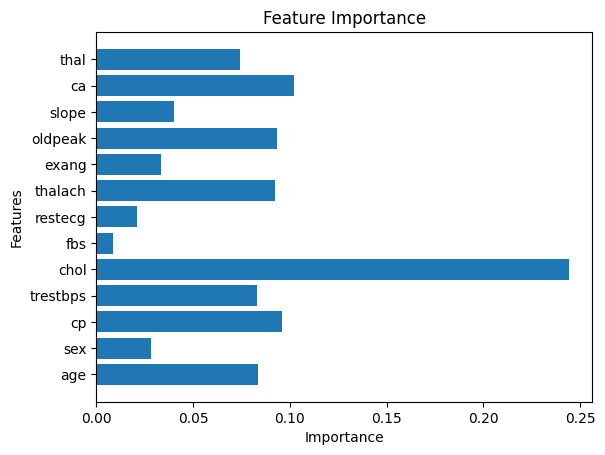

In [14]:
import matplotlib.pyplot as plt

importances = model.feature_importances_
features = X.columns

plt.barh(features, importances)
plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Feature Importance")
plt.show()

### Step 14: Cross-Validation

In [15]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5)

print("Cross-validation scores:", scores)
print("Average CV score:", scores.mean())

Cross-validation scores: [1.         1.         0.98536585 1.         0.98536585]
Average CV score: 0.9941463414634146


### Step 15: Interpretation of Results

In [16]:
for feature, importance in zip(features, importances):
    print(f"{feature}: {importance:.3f}")

age: 0.084
sex: 0.028
cp: 0.096
trestbps: 0.083
chol: 0.244
fbs: 0.009
restecg: 0.021
thalach: 0.092
exang: 0.033
oldpeak: 0.093
slope: 0.040
ca: 0.102
thal: 0.074
